In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
path = "./data/train.csv"

In [4]:
df = pd.read_csv(path).drop(columns=["ID"])

In [5]:
df.shape

(21693, 53)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21693 entries, 0 to 21692
Data columns (total 53 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_01    21693 non-null  float64
 1   X_02    21693 non-null  float64
 2   X_03    21693 non-null  float64
 3   X_04    21693 non-null  float64
 4   X_05    21693 non-null  float64
 5   X_06    21693 non-null  float64
 6   X_07    21693 non-null  float64
 7   X_08    21693 non-null  float64
 8   X_09    21693 non-null  float64
 9   X_10    21693 non-null  float64
 10  X_11    21693 non-null  float64
 11  X_12    21693 non-null  float64
 12  X_13    21693 non-null  float64
 13  X_14    21693 non-null  float64
 14  X_15    21693 non-null  float64
 15  X_16    21693 non-null  float64
 16  X_17    21693 non-null  float64
 17  X_18    21693 non-null  float64
 18  X_19    21693 non-null  float64
 19  X_20    21693 non-null  float64
 20  X_21    21693 non-null  float64
 21  X_22    21693 non-null  float64
 22

In [40]:
df.describe()

,X_01,X_02,X_03,X_04,X_05,X_06,X_07,X_08,X_09,X_10,X_11,X_12,X_13,X_14,X_15,X_16,X_17,X_18,X_19,X_20,X_21,X_22,X_23,X_24,X_25,X_26,X_27,X_28,X_29,X_30,X_31,X_32,X_33,X_34,X_35,X_36,X_37,X_38,X_39,X_40,X_41,X_42,X_43,X_44,X_45,X_46,X_47,X_48,X_49,X_50,X_51,X_52,target
count,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.00000
mean,0.017989,0.258061,0.533411,0.510776,0.421508,0.600059,0.618569,0.534465,0.550514,0.517199,18.918073,0.508895,0.549621,0.378673,0.556958,0.444102,0.517203,0.385823,50.956294,0.570371,0.544510,0.683538,0.583768,0.444814,0.416579,0.542278,0.489117,0.302409,0.564430,0.541562,0.491474,0.523283,0.602839,0.496832,0.438482,0.636854,23.399720,0.405410,0.504725,42.253450,0.757960,0.259099,0.266428,0.453256,0.600050,0.731735,0.408285,0.477403,0.520059,0.582188,0.359334,0.571657,10.00000
std,0.004794,0.064098,0.057962,0.082500,0.168995,0.082645,0.139561,0.153934,0.134451,0.092376,5.059086,0.089030,0.091098,0.078478,0.080348,0.157171,0.092369,0.135133,17.774983,0.129618,0.089303,0.115232,0.063288,0.086558,0.161268,0.127516,0.080758,0.202141,0.097198,0.129341,0.079792,0.111105,0.140204,0.070228,0.094610,0.078670,12.815777,0.137923,0.081603,11.540643,0.100947,0.142885,0.090812,0.072222,0.082649,0.085227,0.137385,0.072804,0.099855,0.065809,0.163723,0.070578,6.05544
min,-0.003000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.235000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.099000,0.000000,0.000000,-0.143000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.015000,0.244223,0.510506,0.507370,0.363789,0.555003,0.642250,0.480822,0.562856,0.463122,17.851000,0.503221,0.533281,0.361728,0.516804,0.440132,0.463158,0.358743,45.703000,0.582319,0.537084,0.696990,0.562553,0.410109,0.360454,0.547052,0.461954,0.231258,0.529993,0.545210,0.476278,0.494107,0.629771,0.480839,0.420435,0.609522,21.576000,0.365445,0.502134,40.956000,0.769803,0.230000,0.255407,0.427448,0.554991,0.739806,0.367151,0.432446,0.511138,0.576432,0.306199,0.559780,5.00000
50%,0.018000,0.247364,0.535398,0.520045,0.378157,0.604917,0.653100,0.504495,0.578888,0.520103,18.155000,0.522643,0.551273,0.371709,0.555396,0.451286,0.520110,0.370589,48.602000,0.597712,0.557286,0.709579,0.585905,0.448983,0.375946,0.556729,0.487840,0.249218,0.556061,0.555236,0.497969,0.538977,0.639821,0.496605,0.436163,0.613535,22.148000,0.377443,0.514592,41.177000,0.778755,0.250000,0.259235,0.442839,0.604909,0.746572,0.379901,0.477400,0.525908,0.589860,0.317177,0.579899,10.00000
75%,0.021000,0.251002,0.560651,0.533285,0.393900,0.651660,0.662580,0.540172,0.593727,0.578334,18.497000,0.538310,0.569030,0.384795,0.597109,0.460356,0.578347,0.380704,52.716000,0.612602,0.574410,0.720934,0.608856,0.486689,0.391947,0.566508,0.514382,0.271131,0.597514,0.565819,0.520542,0.581075,0.648592,0.512537,0.452718,0.619503,22.642000,0.391564,0.526443,41.546000,0.785845,0.270000,0.263090,0.459141,0.651646,0.752450,0.394756,0.523216,0.539435,0.601181,0.329355,0.597964,15.00000
max,0.037000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,92.050000,1.000000,1.000000,1.000000

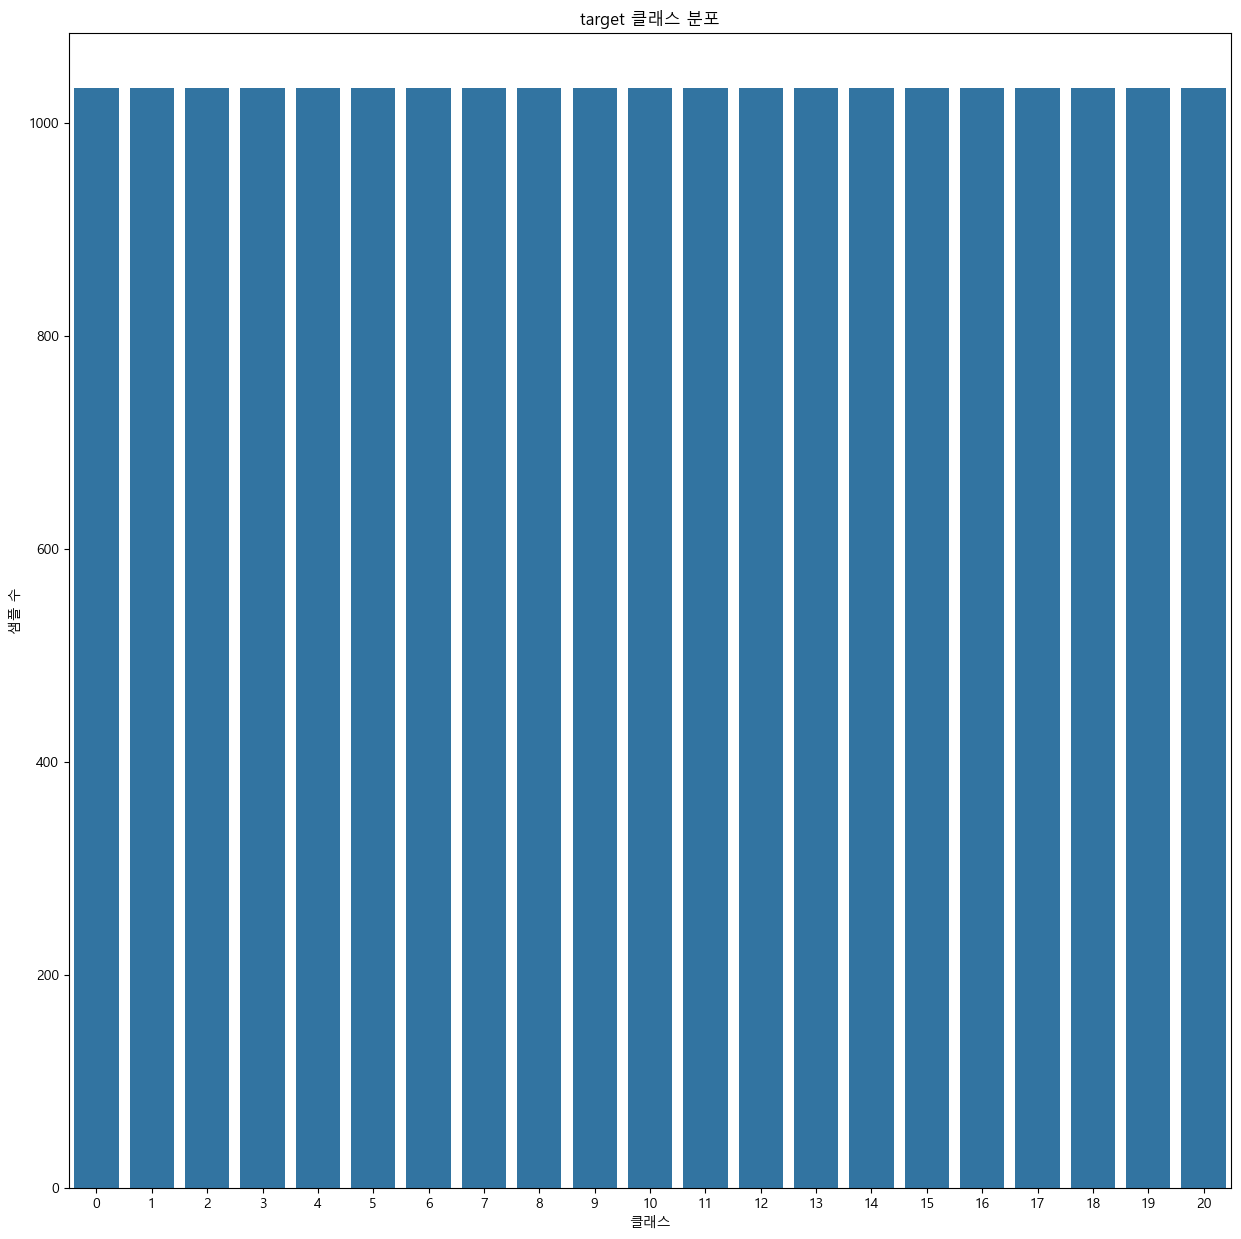

In [9]:
plt.figure(figsize=(15,15))
sns.barplot(x = df["target"].value_counts().index, y = df["target"].value_counts().values)
plt.title("target 클래스 분포")
plt.xlabel("클래스")
plt.ylabel("샘플 수")
plt.show()

<Figure size 1400x1200 with 0 Axes>

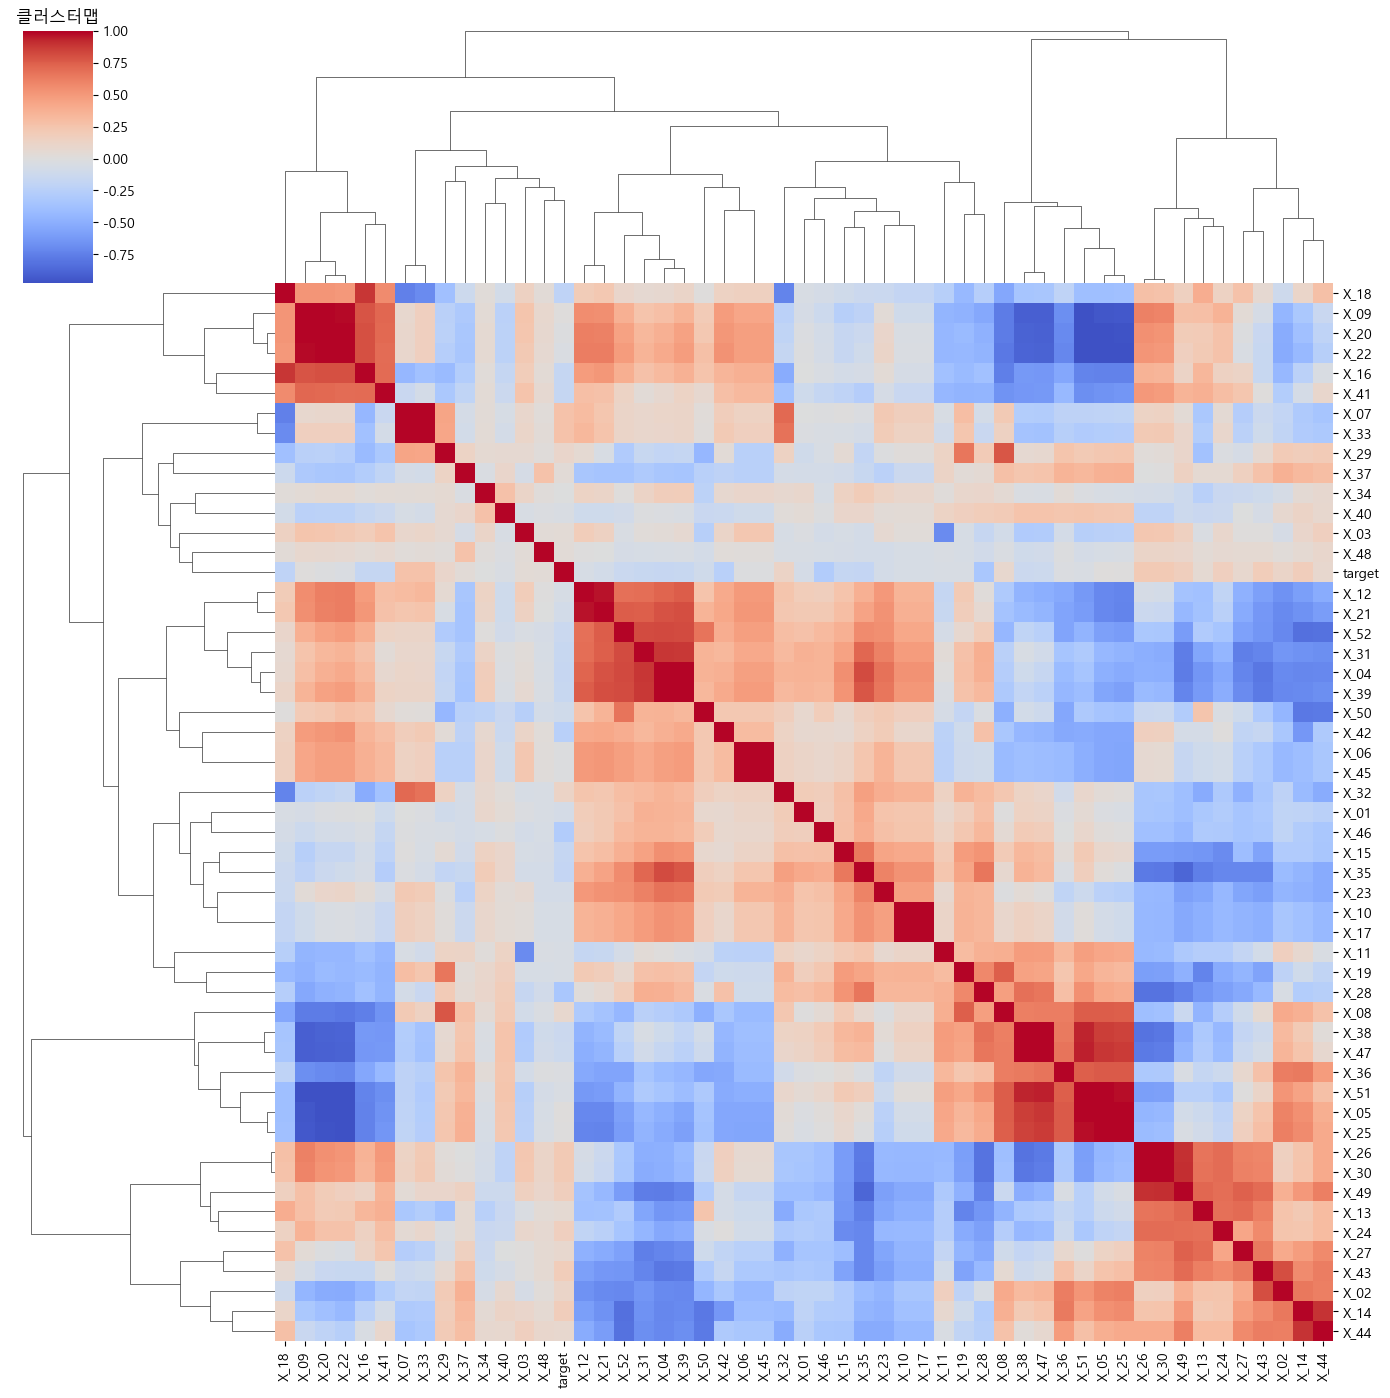

In [41]:
corr = df.copy().corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 12))
sns.clustermap(corr, cmap="coolwarm", center=0, figsize=(14, 14))
plt.title("클러스터맵")
plt.show()

In [42]:
df = pd.read_csv(path).drop(columns=["ID"])
feature_cols = [c for c in df.columns if c != "target"]
X = df[feature_cols].copy()

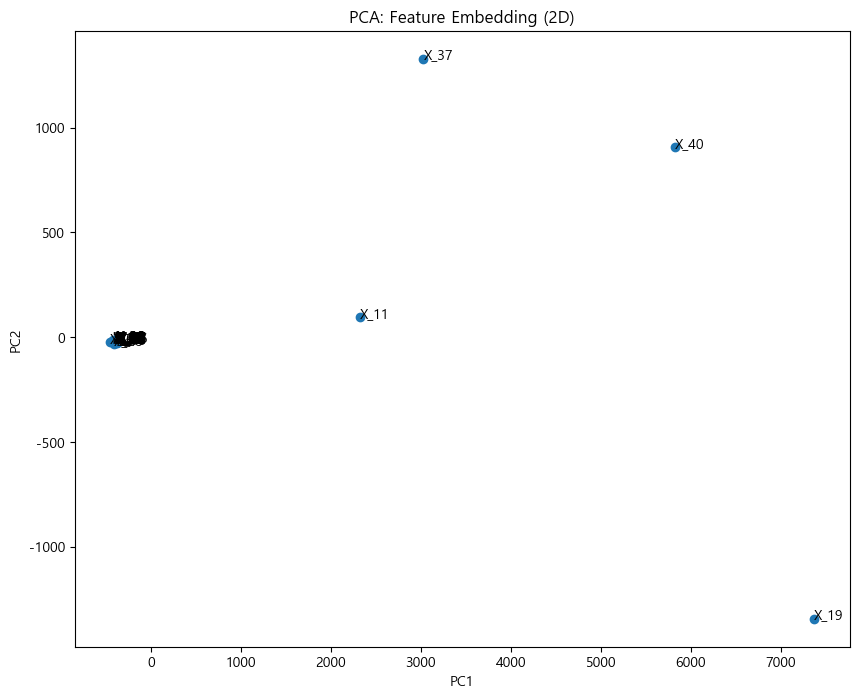

Explained variance ratio: [0.93244306 0.03749399]


In [ ]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.T)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

for i, feature in enumerate(X.columns):
    plt.text(X_pca[i, 0], X_pca[i, 1], feature)

plt.title("PCA: Feature Embedding (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

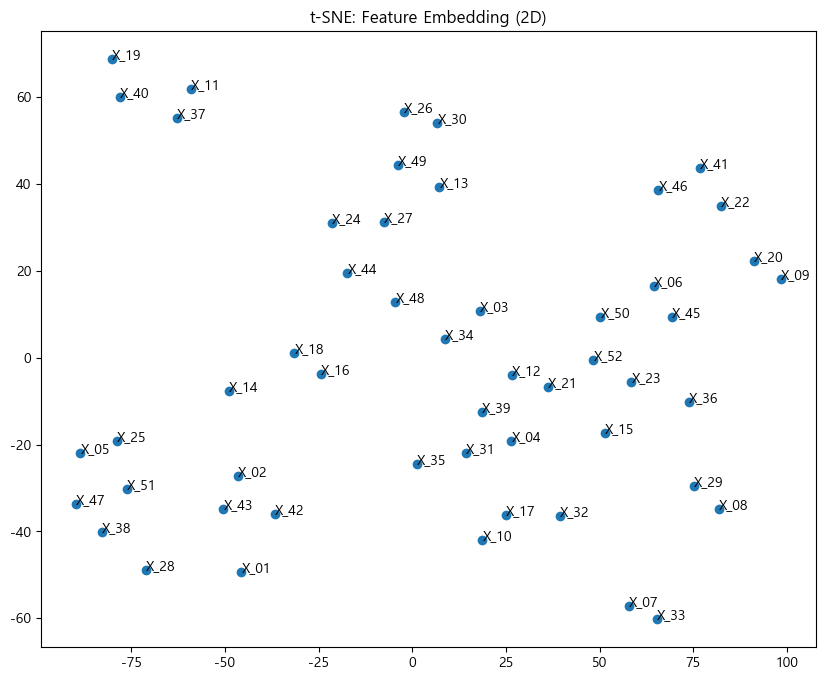

In [ ]:
# T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
X_tsne = tsne.fit_transform(X.T)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])

for i, feature in enumerate(X.columns):
    plt.text(X_tsne[i, 0], X_tsne[i, 1], feature)

plt.title("t-SNE: Feature Embedding (2D)")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

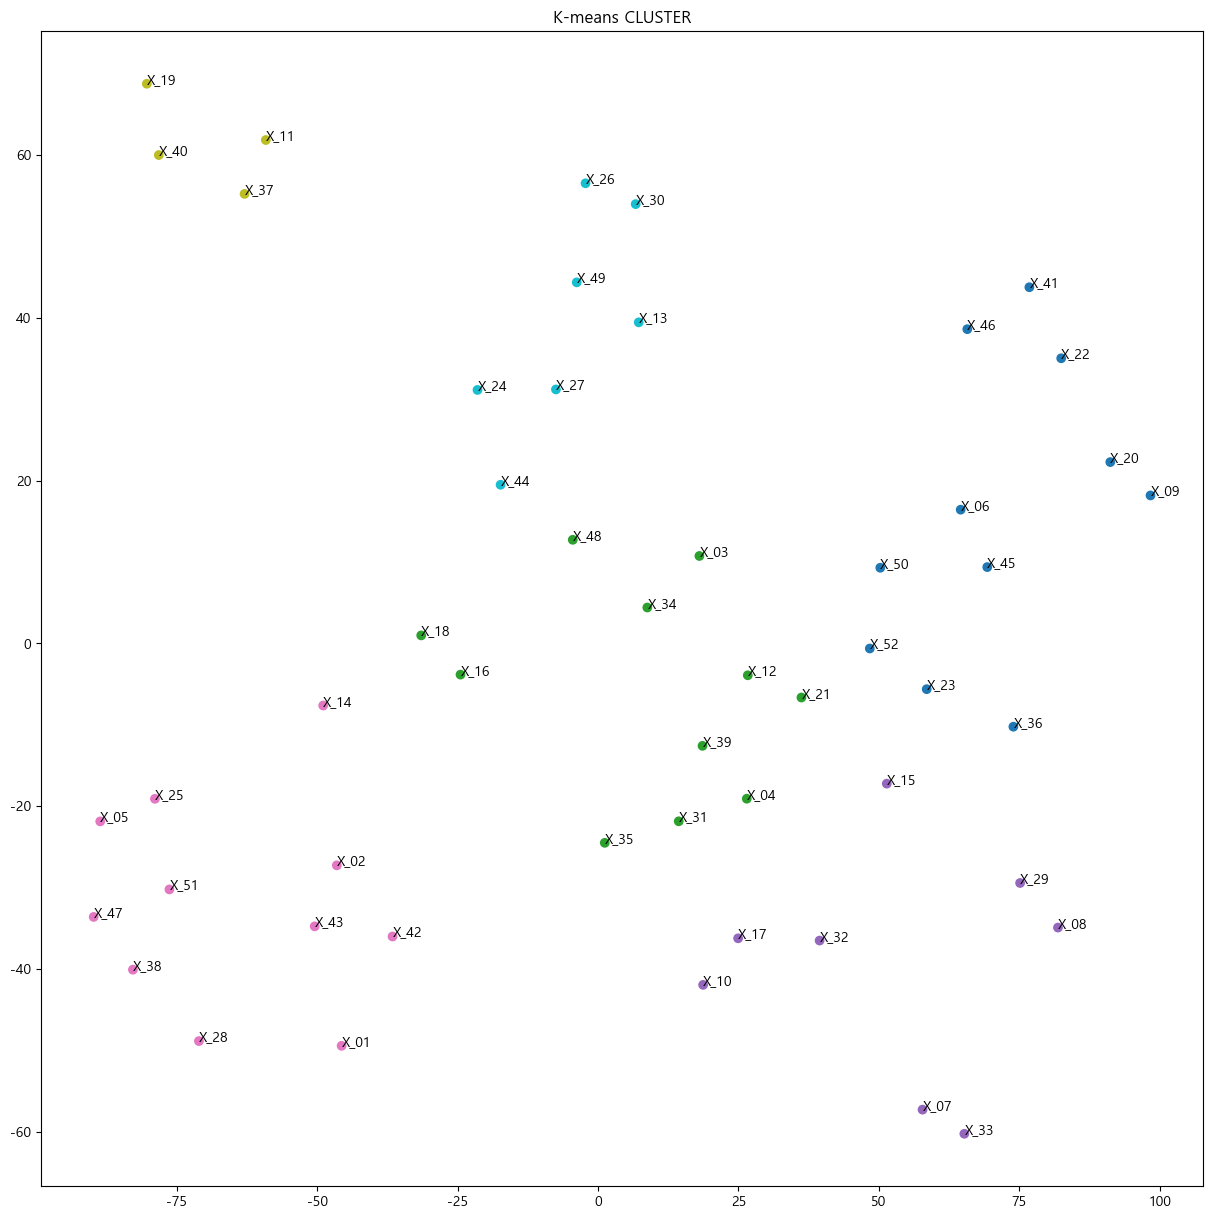

In [ ]:
# T-SNE를 통해 나온 결과를 클러스터링
kmeans = KMeans(n_clusters=6, random_state=42)
cluster = kmeans.fit_predict(X_tsne)
plt.figure(figsize=(15,15))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=cluster, cmap="tab10")
for i, feature in enumerate(X.columns):
    plt.text(X_tsne[i,0], X_tsne[i,1], feature)
plt.title("K-means CLUSTER")
plt.show

In [ ]:
# target과 상관관계 데이터프레임 제작
corr_with_target = df[feature_cols + ["target"]].corr()["target"].drop("target").abs()

df_cluster = pd.DataFrame({
    "feature": feature_cols,
    "cluster": cluster,
    "corr_with_target": corr_with_target.reindex(feature_cols).values
})
df_cluster.head(10)

,feature,cluster,corr_with_target
0,X_01,3,0.068221
1,X_02,3,0.113243
2,X_03,1,0.038663
3,X_04,1,0.161904
4,X_05,3,0.005533
5,X_06,0,0.016031
6,X_07,2,0.261217
7,X_08,2,0.075045
8,X_09,0,0.005156
9,X_10,2,0.051950


In [ ]:
# 각 클러스터에서 target과 상관관계가 큰 대표 피쳐 추출
selected_features = (
    df_cluster.sort_values(["cluster", "corr_with_target"], ascending=[True, False])
              .groupby("cluster", as_index=False)
              .head(4)
)
selected_features

,feature,cluster,corr_with_target
45,X_46,0,0.285657
40,X_41,0,0.167014
51,X_52,0,0.137073
49,X_50,0,0.098097
17,X_18,1,0.209667
34,X_35,1,0.175724
15,X_16,1,0.168374
3,X_04,1,0.161904
32,X_33,2,0.266976
6,X_07,2,0.261217


In [ ]:
# 다중공선성 제거
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
high_corr_features = [c for c in upper.columns if any(upper[c] > 0.9)]

X_scaled = (X - X.mean()) / X.std()
vif_df = pd.DataFrame({
    "feature": feature_cols,
    "VIF": [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
})

In [ ]:
# 공선성을 제외한 뒤 최종 feature 추출
topN = corr_with_target.sort_values(ascending=False).head(15).index.tolist()
candidate = set(selected_features["feature"]).union(topN)
drop_by_corr = set(high_corr_features)
drop_by_vif  = set(vif_df.loc[vif_df["VIF"] > 10, "feature"])

final_features = sorted(list(candidate - drop_by_corr - drop_by_vif))
print("최종 feature 리스트:", final_features)

최종 feature 리스트: ['X_11', 'X_15', 'X_24', 'X_32', 'X_37', 'X_40', 'X_41', 'X_46']
